In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier


In [2]:
file_path = r"C:\Users\KARTHIK\OneDrive\Desktop\construction_project_dataset_5500_with_duplicates_nulls.csv"

data = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Shape of dataset:")
print(data.shape)

print("\nFirst 5 rows:")
display(data.head())

print("\nLast 5 rows:")
display(data.tail())

Shape of dataset:
(5500, 19)

First 5 rows:


,timestamp,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency,optimization_suggestion,performance_score
0,2023-02-03 18:05:00,31.691912,46.649940,2.146990,599.183208,1.0,12.0,121.905317,100.0,3314.534772,-6.521320,0.0,86.888147,0.0,89.644353,2.324519,5.0,Optimize Material Usage,Excellent
1,2023-01-03 15:24:00,21.491771,70.054412,12.326874,678.002039,0.0,NaN,383.855798,100.0,-2393.597210,0.284285,0.0,56.440862,0.0,40.061996,5.309876,10.0,Optimize Material Usage,Excellent
2,2023-01-26 15:55:00,34.438672,21.410405,17.183166,875.712543,1.0,25.0,148.483460,100.0,NaN,NaN,0.0,83.992150,0.0,10.784954,4.418866,15.0,Adjust Schedule,Excellent
3,2023-01-08 09:09:00,28.117210,71.822461,1.097430,738.283567,1.0,37.0,86.186208,100.0,415.094048,2.900278,0.0,83.984972,0.0,31.035249,4.971245,5.0,Optimize Material Usage,Excellent
4,2023-01-29 19:17:00,25.086549,63.033063,11.493353,675.190145,1.0,8.0,480.193340,100.0,-4499.154125,2.032765,0.0,89.421951,0.0,74.666141,0.379354,10.0,Reallocate Workers,NaN



Last 5 rows:


,timestamp,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency,optimization_suggestion,performance_score
5495,2023-02-02 17:33:00,15.256036,47.624423,16.562652,632.425197,1.0,47.0,422.845278,100.000000,-1561.747648,-1.627918,0.0,NaN,0.0,21.299124,8.224893,10.0,Adjust Schedule,Excellent
5496,2023-01-24 04:07:00,33.054474,29.711470,48.110654,565.119122,1.0,8.0,84.632562,NaN,-2137.629330,-4.183136,0.0,83.964847,0.0,60.383684,2.296021,5.0,Increase Machinery,Excellent
5497,2023-01-01 21:48:00,23.486255,24.198330,37.257600,717.096481,1.0,34.0,355.387263,73.434548,-4449.772744,-9.206382,0.0,80.592181,0.0,12.619477,7.952248,15.0,Adjust Schedule,Excellent
5498,2023-01-20 12:28:00,20.807192,56.884974,0.924141,351.872954,NaN,36.0,319.689464,100.000000,2002.454801,4.142418,0.0,60.376560,NaN,80.056898,8.883847,10.0,Increase Machinery,Excellent
5499,2023-01-22 04:08:00,15.413399,36.413092,16.650691,701.872065,0.0,21.0,272.746018,100.000000,-424.842055,7.450483,0.0,56.559889,NaN,15.406807,1.315257,10.0,NaN,Excellent


In [4]:
print("Number of columns:", len(data.columns))

print("\nColumns:")
for i, column in enumerate(data.columns, start=1):
    print(i, "→", column)

Number of columns: 19

Columns:
1 → timestamp
2 → temperature
3 → humidity
4 → vibration_level
5 → material_usage
6 → machinery_status
7 → worker_count
8 → energy_consumption
9 → task_progress
10 → cost_deviation
11 → time_deviation
12 → safety_incidents
13 → equipment_utilization_rate
14 → material_shortage_alert
15 → risk_score
16 → simulation_deviation
17 → update_frequency
18 → optimization_suggestion
19 → performance_score


In [5]:
print(data.dtypes)

timestamp                      object
temperature                   float64
humidity                      float64
vibration_level               float64
material_usage                float64
machinery_status              float64
worker_count                  float64
energy_consumption            float64
task_progress                 float64
cost_deviation                float64
time_deviation                float64
safety_incidents              float64
equipment_utilization_rate    float64
material_shortage_alert       float64
risk_score                    float64
simulation_deviation          float64
update_frequency              float64
optimization_suggestion        object
performance_score              object
dtype: object


In [6]:
numeric_columns = data.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = data.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['temperature', 'humidity', 'vibration_level', 'material_usage', 'machinery_status', 'worker_count', 'energy_consumption', 'task_progress', 'cost_deviation', 'time_deviation', 'safety_incidents', 'equipment_utilization_rate', 'material_shortage_alert', 'risk_score', 'simulation_deviation', 'update_frequency']

Categorical columns:
['timestamp', 'optimization_suggestion', 'performance_score']


In [7]:
missing = data.isnull().sum()

missing_percentage = (
    data.isnull().sum() / len(data) * 100
)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_report = missing_report.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_report)

,Missing Count,Missing Percentage
safety_incidents,298,5.418182
material_shortage_alert,296,5.381818
worker_count,294,5.345455
material_usage,288,5.236364
humidity,286,5.200000
timestamp,285,5.181818
optimization_suggestion,282,5.127273
risk_score,276,5.018182
cost_deviation,275,5.000000
equipment_utilization_rate,271,4.927273


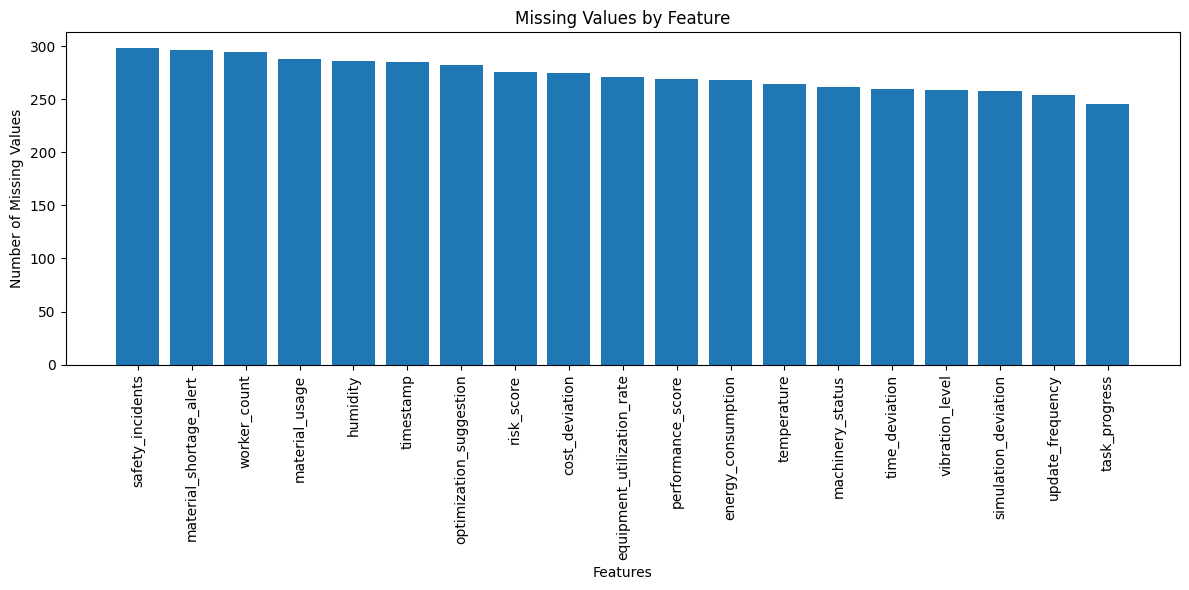

In [8]:
plt.figure(figsize=(12, 6))

plt.bar(
    missing_report.index,
    missing_report["Missing Count"]
)

plt.xticks(
    rotation=90
)

plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values by Feature")

plt.tight_layout()
plt.show()

In [9]:
duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 79


In [10]:
data_clean = data.drop_duplicates().copy()

print("Original shape:", data.shape)
print("After removing duplicates:", data_clean.shape)

Original shape: (5500, 19)
After removing duplicates: (5421, 19)


In [11]:
print(
    "Duplicates after removal:",
    data_clean.duplicated().sum()
)

Duplicates after removal: 0


In [12]:
display(
    data_clean.describe().T
)

,count,mean,std,min,25%,50%,75%,max
temperature,5159.0,27.452819,7.218164,15.001687,21.128694,27.392204,33.715834,39.995594
humidity,5138.0,49.819771,17.163440,20.001761,34.785372,49.974685,64.662745,79.999523
vibration_level,5163.0,24.968564,14.403474,0.001829,12.628825,24.709310,37.329055,49.999469
material_usage,5143.0,553.186262,260.200209,100.005915,329.549946,550.449734,778.172718,999.694284
machinery_status,5164.0,0.697134,0.459542,0.000000,0.000000,1.000000,1.000000,1.000000
worker_count,5135.0,26.868354,13.072369,5.000000,15.000000,27.000000,38.000000,49.000000
energy_consumption,5157.0,275.192629,131.427385,50.073147,160.157645,275.126293,392.225901,499.926351
task_progress,5180.0,98.176645,10.951642,0.185736,100.000000,100.000000,100.000000,100.000000
cost_deviation,5153.0,24.838956,2892.362774,-4999.600496,-2487.216153,92.973578,2516.705884,4999.411695
time_deviation,5164.0,0.022192,5.758664,-9.992252,-4.959895,0.013873,4.978737,9.996949


In [13]:
for column in data_clean.columns:
    print(
        f"{column}:",
        data_clean[column].nunique(),
        "unique values"
    )

timestamp: 5139 unique values
temperature: 5159 unique values
humidity: 5138 unique values
vibration_level: 5163 unique values
material_usage: 5143 unique values
machinery_status: 2 unique values
worker_count: 45 unique values
energy_consumption: 5157 unique values
task_progress: 185 unique values
cost_deviation: 5153 unique values
time_deviation: 5164 unique values
safety_incidents: 4 unique values
equipment_utilization_rate: 5154 unique values
material_shortage_alert: 2 unique values
risk_score: 5150 unique values
simulation_deviation: 5166 unique values
update_frequency: 3 unique values
optimization_suggestion: 4 unique values
performance_score: 1 unique values


In [14]:
data_clean["timestamp"] = pd.to_datetime(
    data_clean["timestamp"],
    errors="coerce"
)

In [15]:
data_clean["hour"] = (
    data_clean["timestamp"].dt.hour
)

data_clean["day"] = (
    data_clean["timestamp"].dt.day
)

data_clean["dayofweek"] = (
    data_clean["timestamp"].dt.dayofweek
)

data_clean["month"] = (
    data_clean["timestamp"].dt.month
)

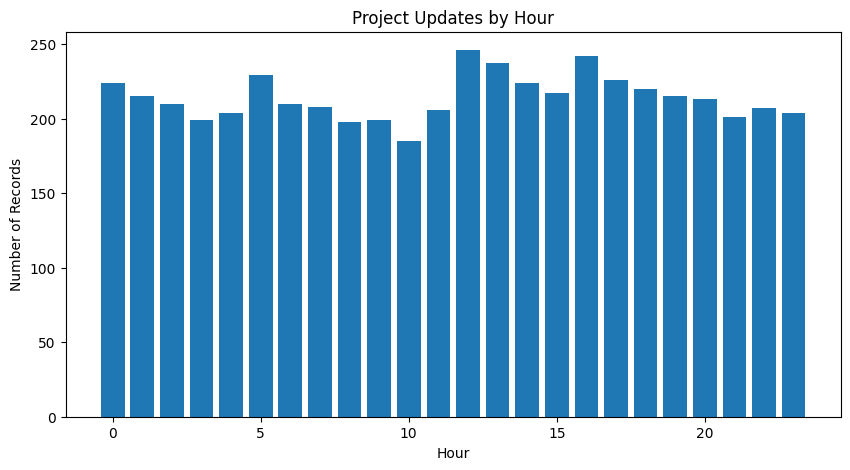

In [16]:
hour_counts = data_clean["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(
    hour_counts.index,
    hour_counts.values
)

plt.xlabel("Hour")
plt.ylabel("Number of Records")
plt.title("Project Updates by Hour")

plt.show()

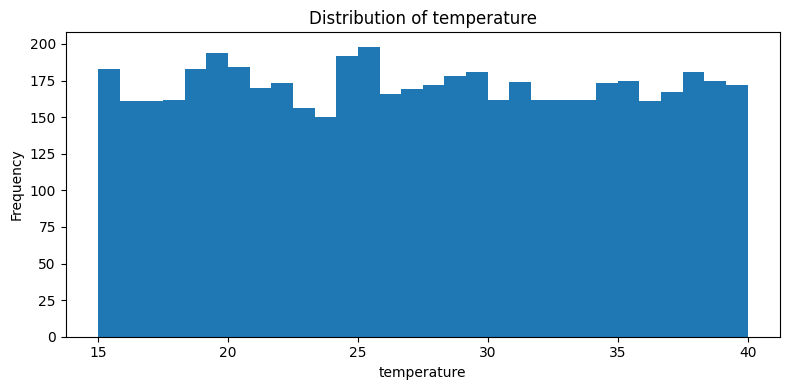

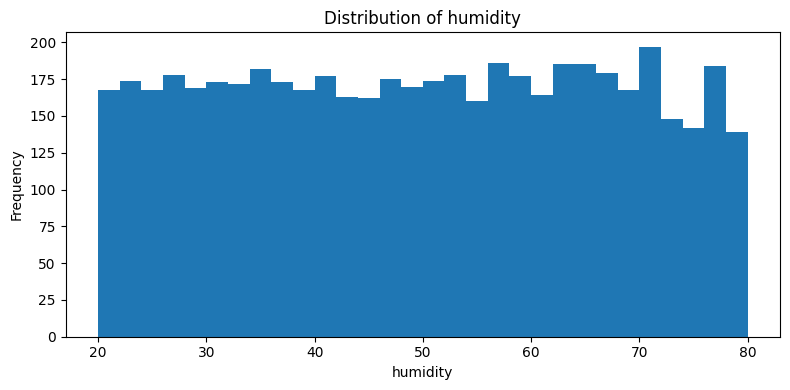

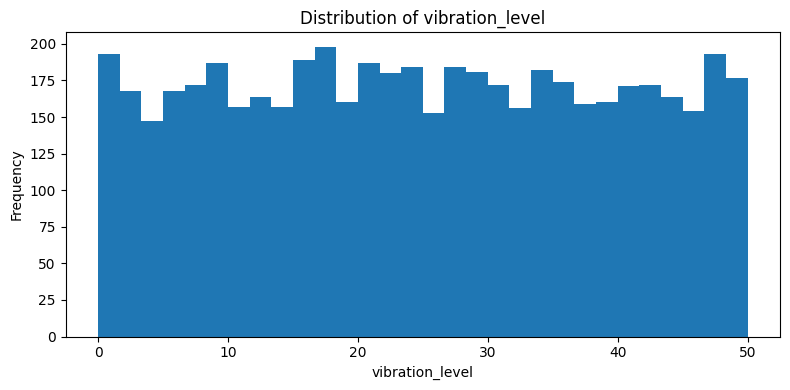

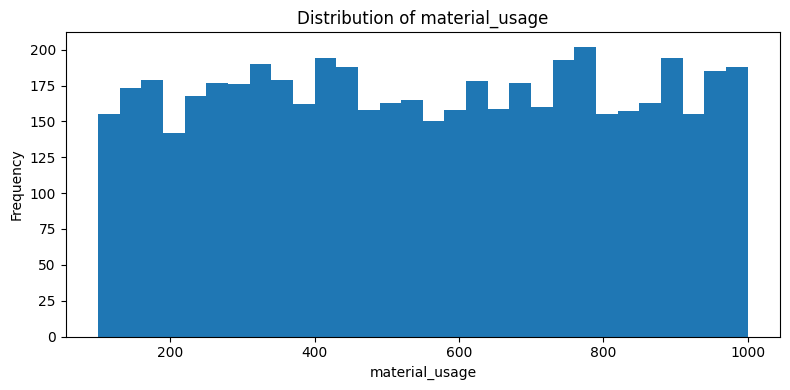

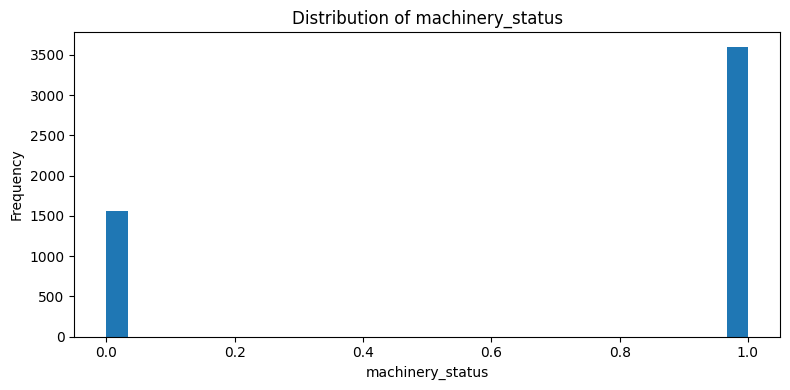

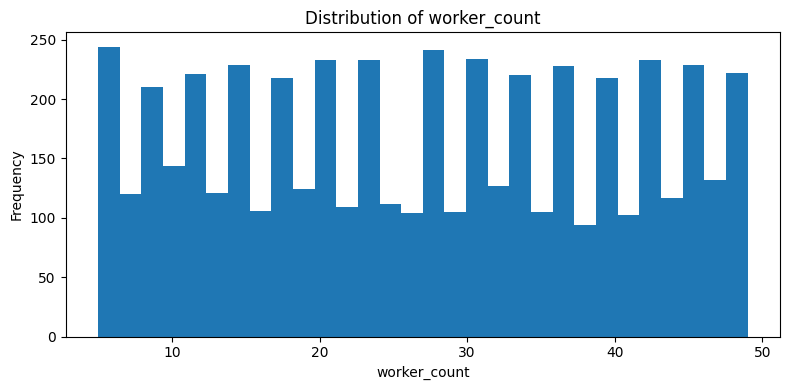

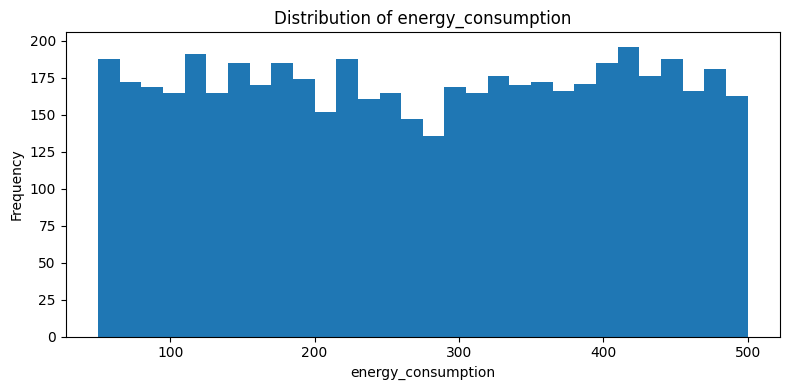

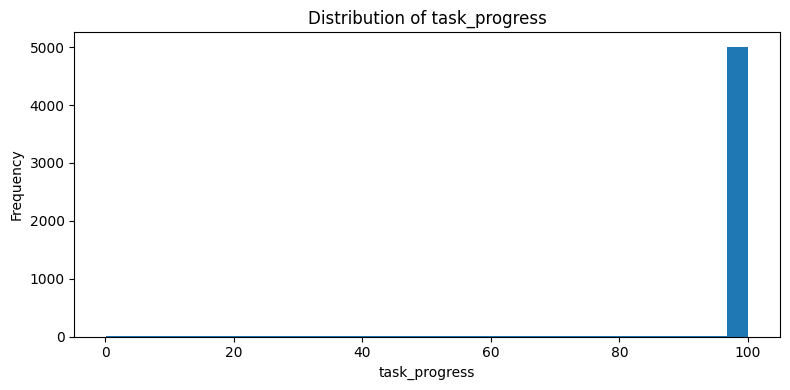

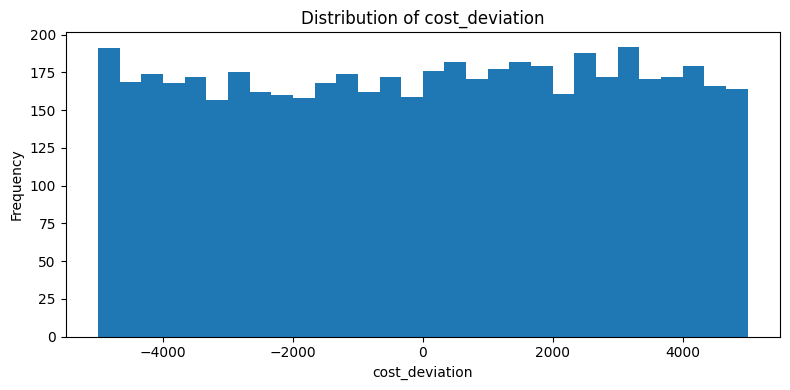

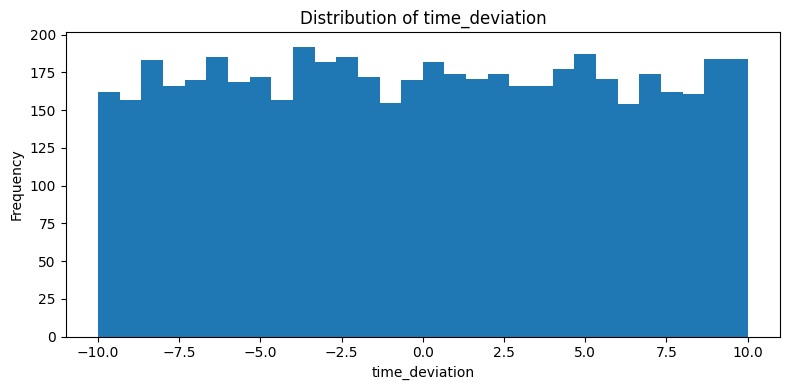

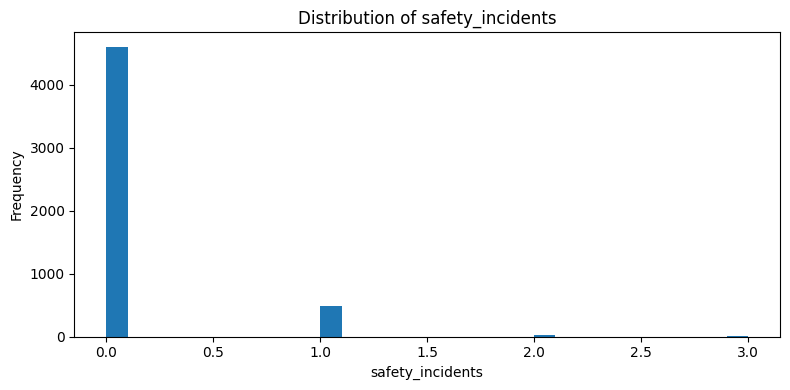

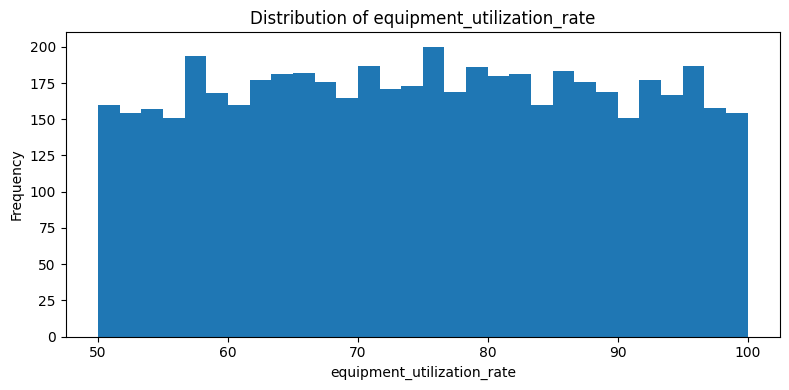

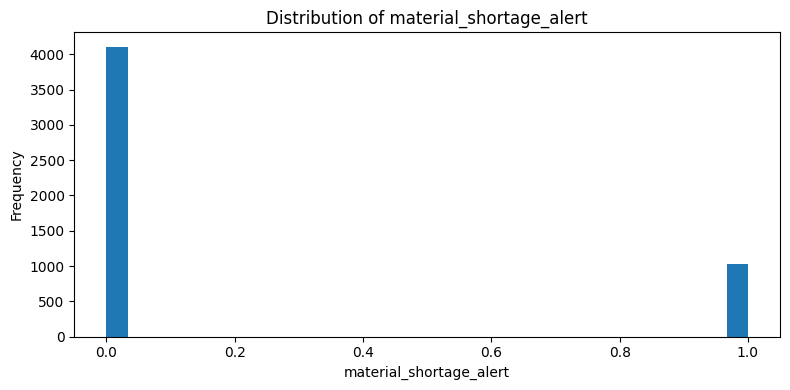

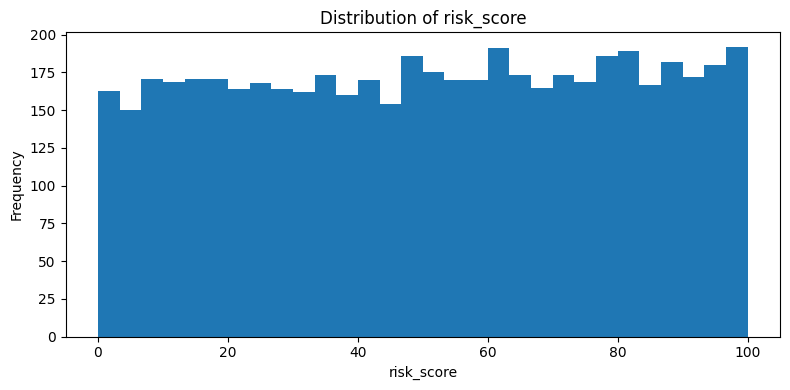

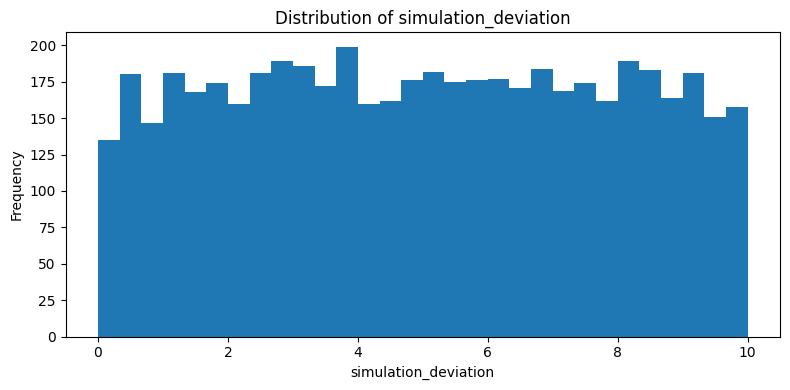

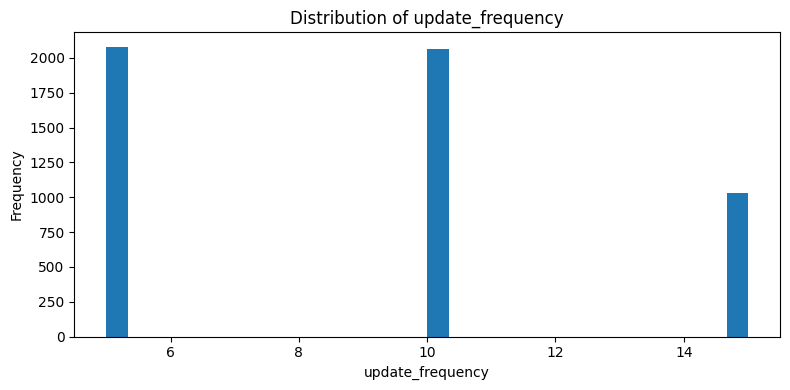

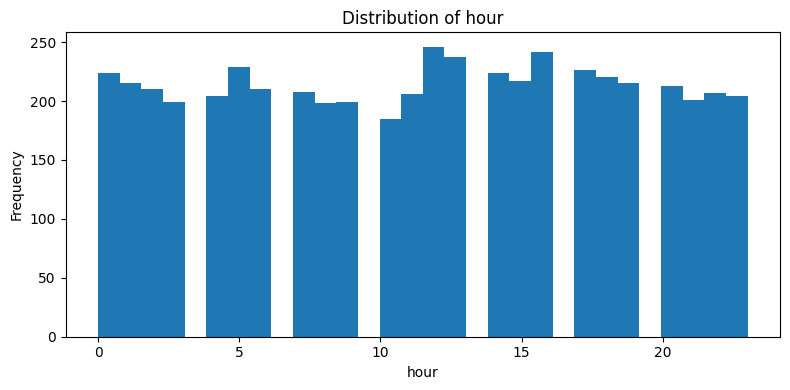

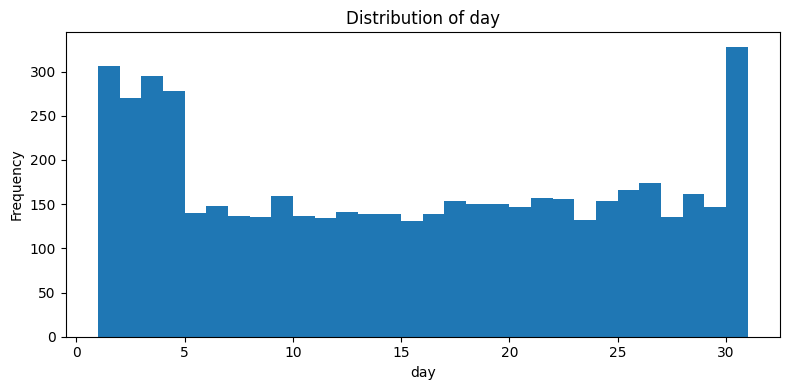

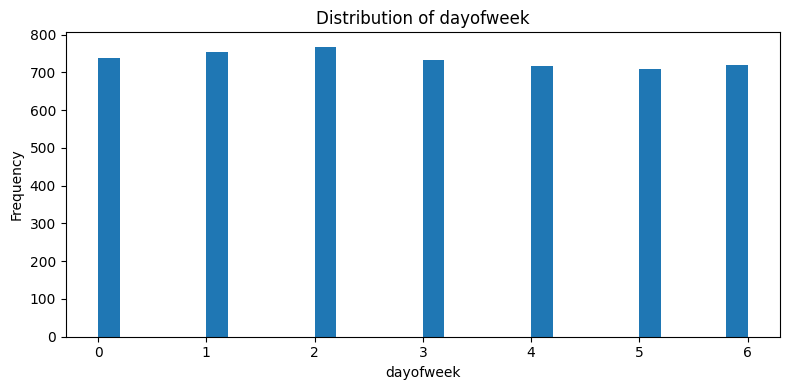

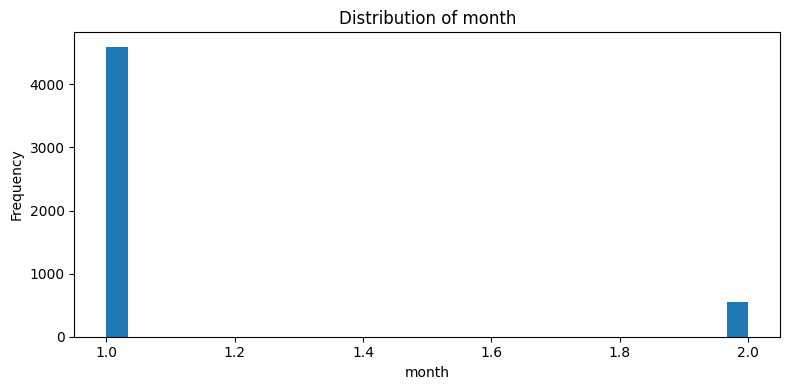

In [17]:
numeric_columns = data_clean.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    plt.hist(
        data_clean[column].dropna(),
        bins=30
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(
        f"Distribution of {column}"
    )

    plt.tight_layout()
    plt.show()

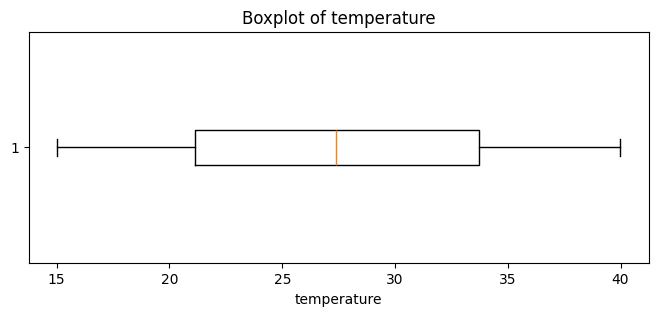

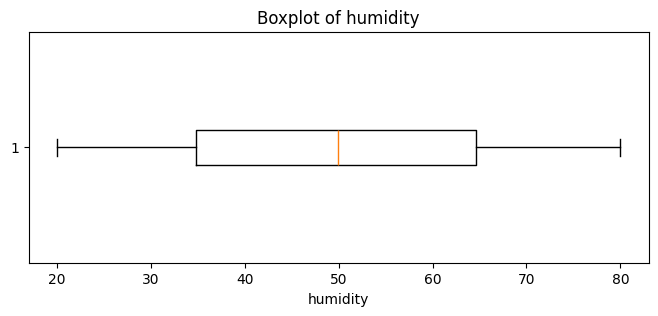

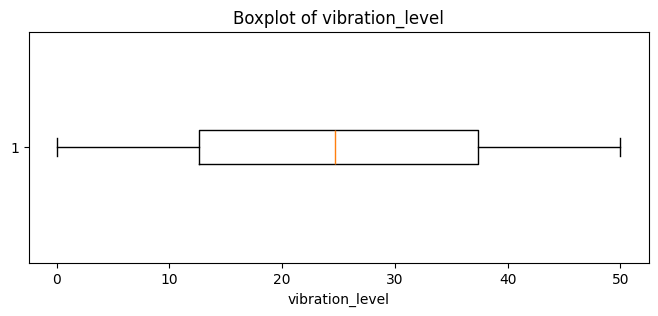

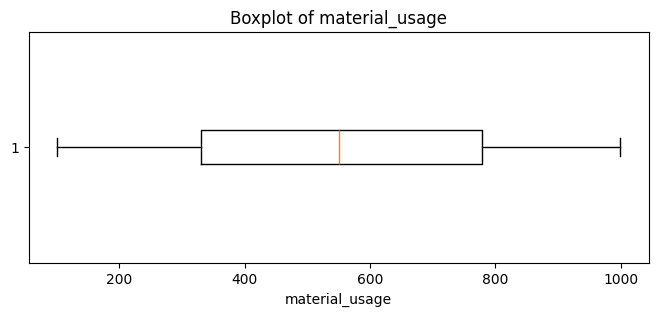

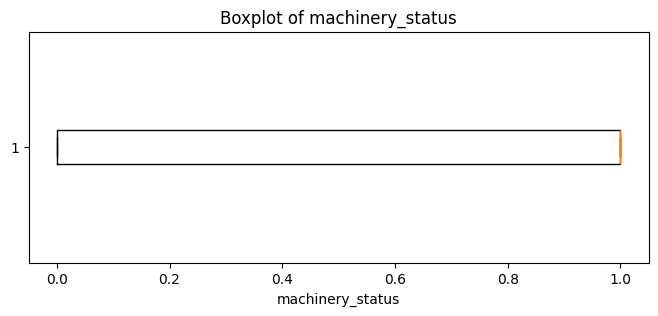

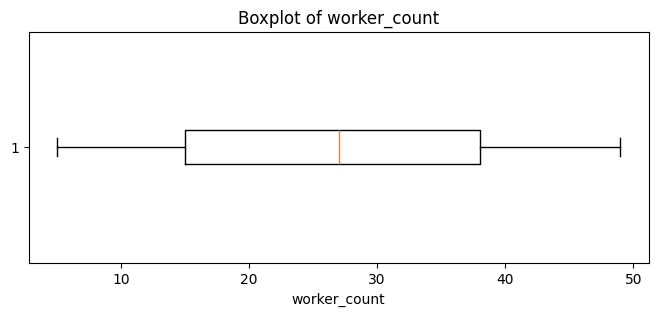

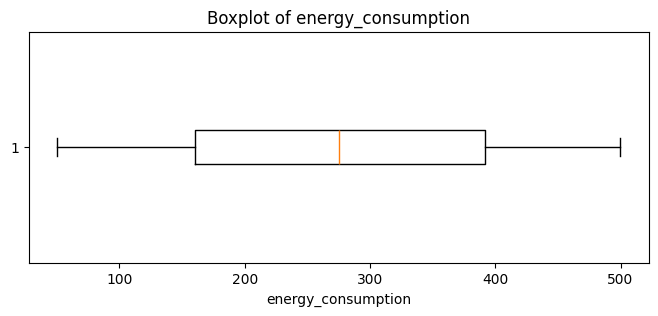

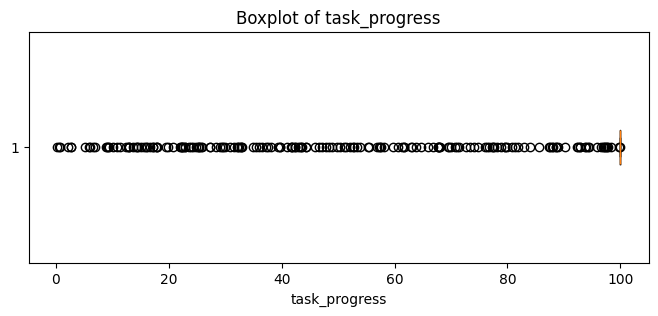

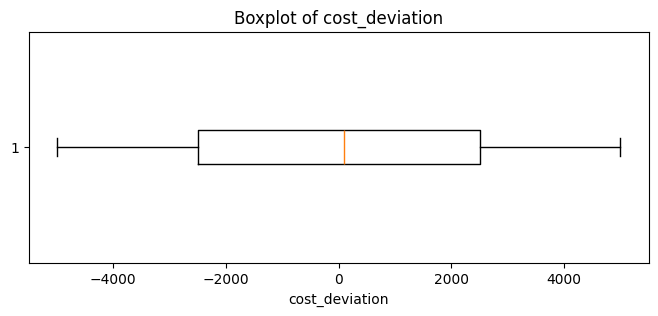

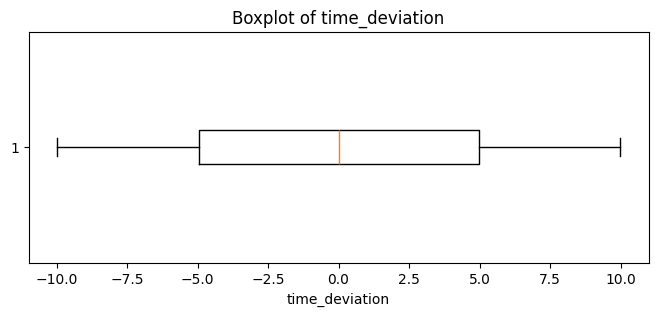

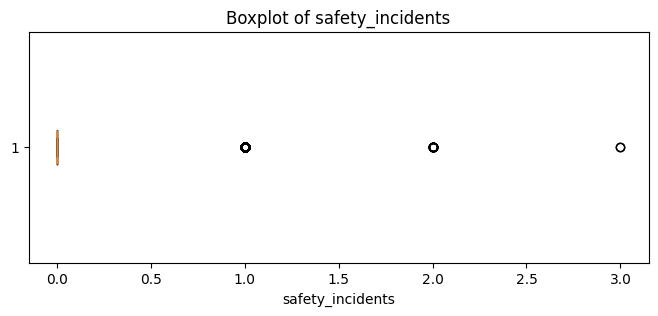

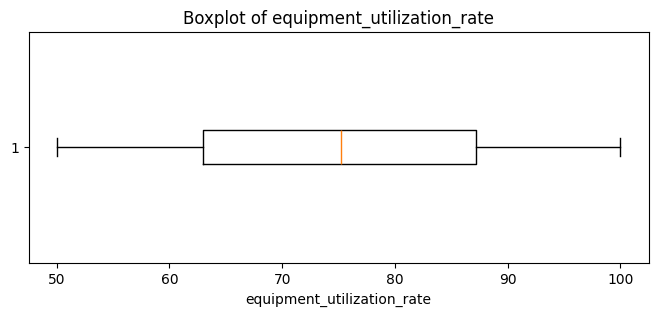

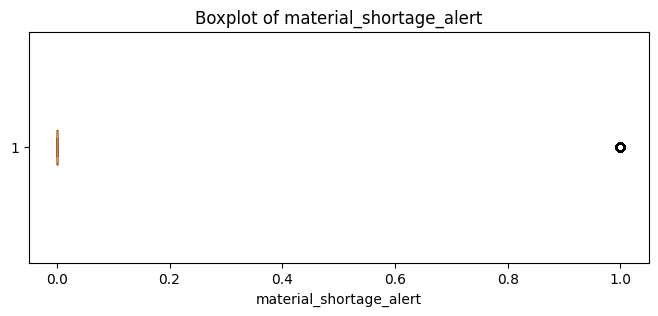

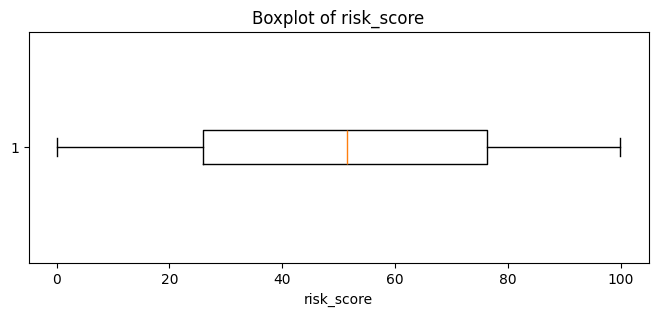

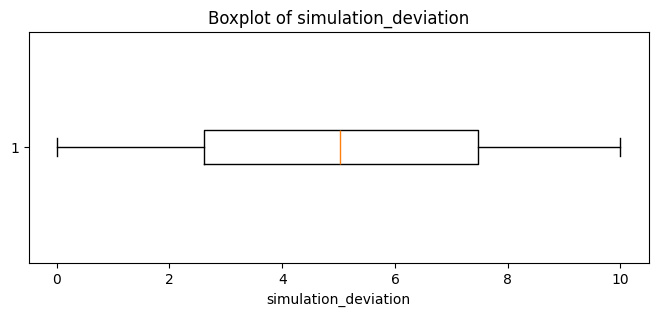

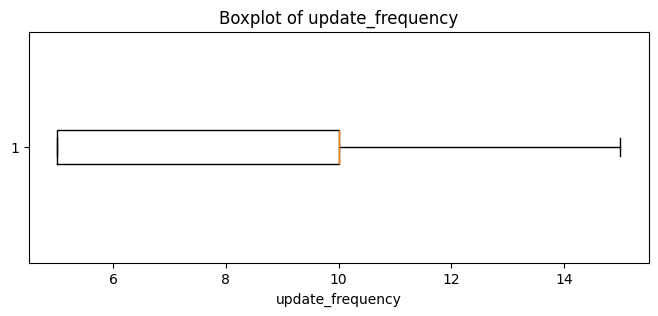

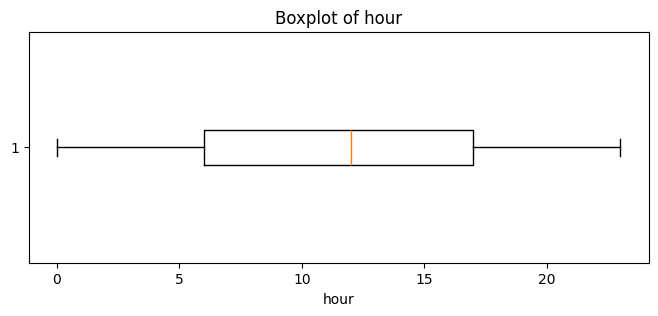

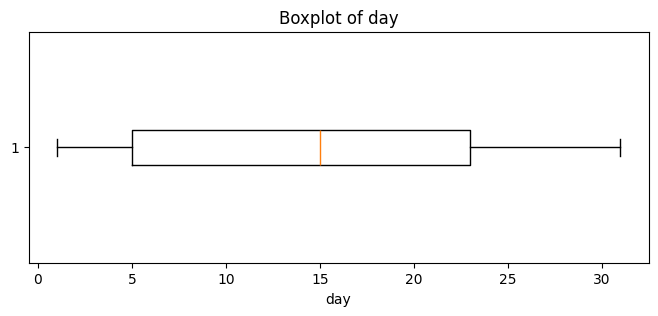

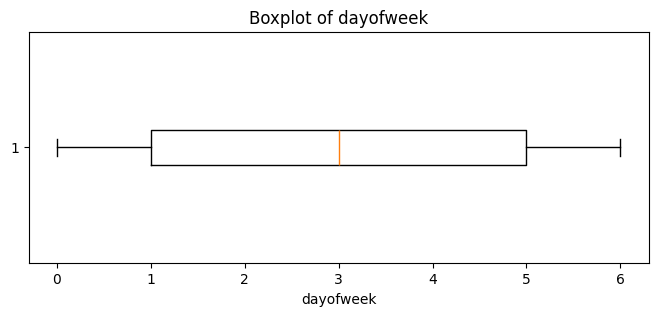

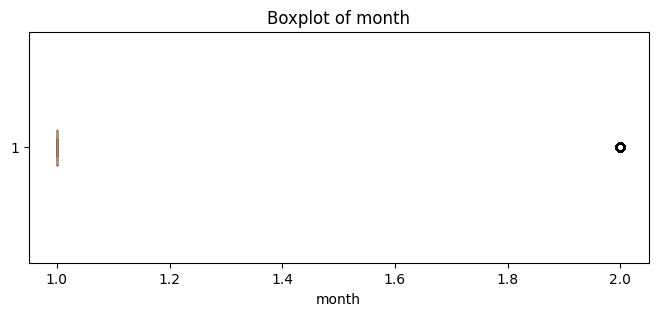

In [18]:
for column in numeric_columns:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        data_clean[column].dropna(),
        vert=False
    )

    plt.xlabel(column)
    plt.title(
        f"Boxplot of {column}"
    )

    plt.show()

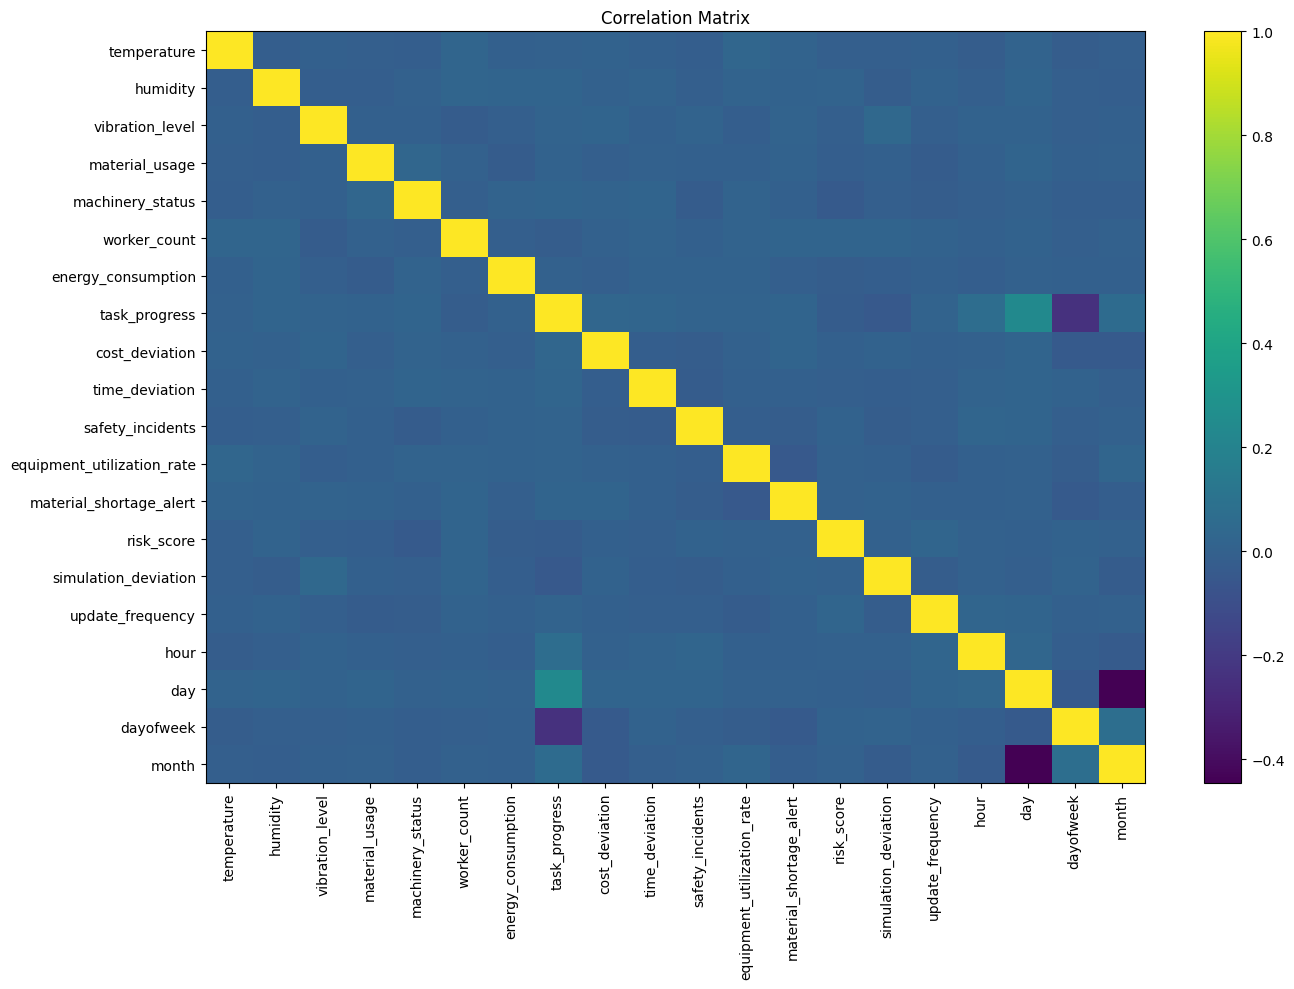

In [19]:
correlation = data_clean.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

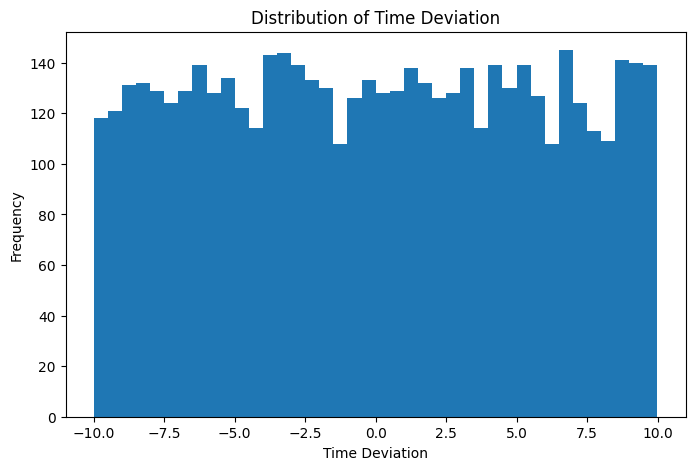

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    data_clean["time_deviation"].dropna(),
    bins=40
)

plt.xlabel("Time Deviation")
plt.ylabel("Frequency")
plt.title("Distribution of Time Deviation")

plt.show()

In [21]:
data_clean["Delay"] = (
    data_clean["time_deviation"] > 0
).astype(int)

In [22]:
data_clean["worker_productivity"] = (
    data_clean["task_progress"] /
    (data_clean["worker_count"] + 1)
)

In [23]:
data_clean["material_efficiency"] = (
    data_clean["task_progress"] /
    (data_clean["material_usage"] + 1)
)

In [24]:
data_clean["equipment_efficiency"] = (
    data_clean["task_progress"] /
    (data_clean["energy_consumption"] + 1)
)

In [25]:
data_clean["environmental_stress"] = (
    data_clean["temperature"] *
    data_clean["humidity"] / 100
)

In [26]:
data_clean["safety_risk"] = (
    data_clean["safety_incidents"] *
    data_clean["risk_score"]
)

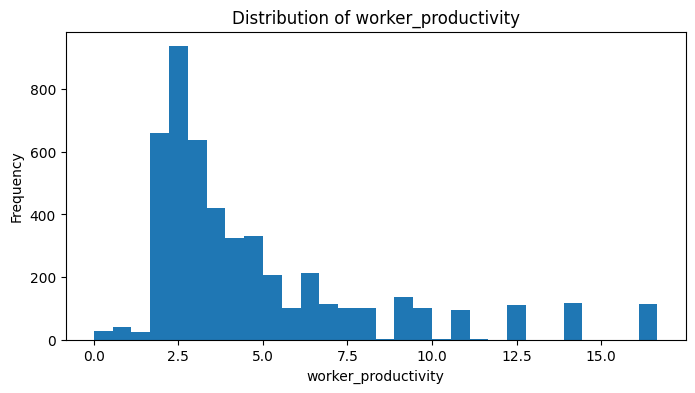

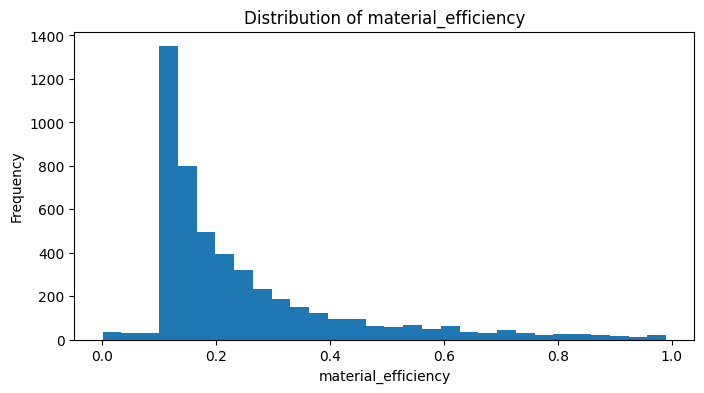

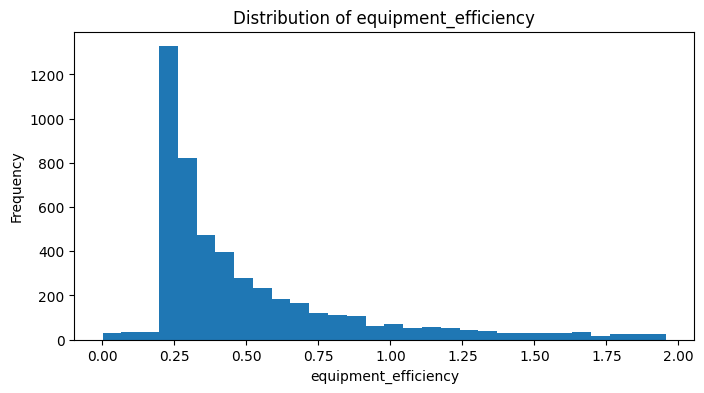

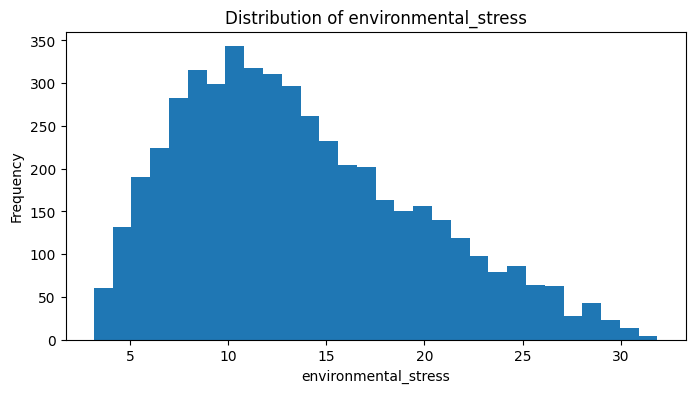

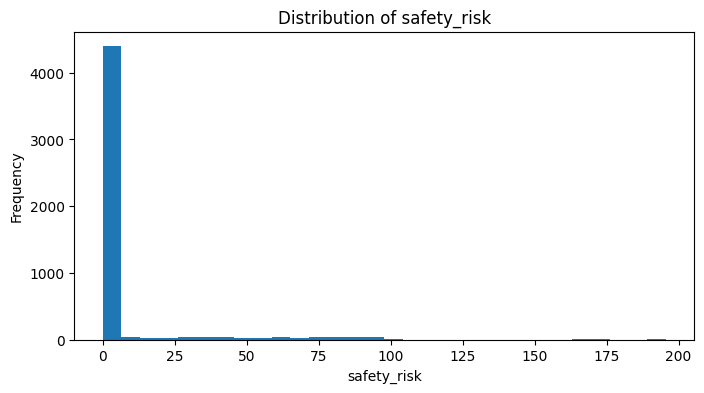

In [27]:
engineered_features = [
    "worker_productivity",
    "material_efficiency",
    "equipment_efficiency",
    "environmental_stress",
    "safety_risk"
]

for column in engineered_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        data_clean[column].replace(
            [np.inf, -np.inf],
            np.nan
        ).dropna(),
        bins=30
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(
        f"Distribution of {column}"
    )

    plt.show()

In [28]:
data_clean.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [29]:
numeric_columns = data_clean.select_dtypes(
    include=np.number
).columns

numeric_imputer = SimpleImputer(
    strategy="median"
)

data_clean[numeric_columns] = (
    numeric_imputer.fit_transform(
        data_clean[numeric_columns]
    )
)

In [30]:
categorical_columns = data_clean.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:

    data_clean[column] = (
        data_clean[column]
        .fillna(
            data_clean[column].mode()[0]
        )
    )

In [31]:
print(
    data_clean.isnull().sum()
)

timestamp                     282
temperature                     0
humidity                        0
vibration_level                 0
material_usage                  0
machinery_status                0
worker_count                    0
energy_consumption              0
task_progress                   0
cost_deviation                  0
time_deviation                  0
safety_incidents                0
equipment_utilization_rate      0
material_shortage_alert         0
risk_score                      0
simulation_deviation            0
update_frequency                0
optimization_suggestion         0
performance_score               0
hour                            0
day                             0
dayofweek                       0
month                           0
Delay                           0
worker_productivity             0
material_efficiency             0
equipment_efficiency            0
environmental_stress            0
safety_risk                     0
dtype: int64


In [32]:
def min_max(series):

    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0,
            index=series.index
        )

    return (
        (series - minimum) /
        (maximum - minimum)
    )

In [33]:
data_clean["delay_risk_score"] = (

    0.25 *
    min_max(
        data_clean["risk_score"]
    )

    + 0.20 *
    min_max(
        data_clean["cost_deviation"]
    )

    + 0.15 *
    min_max(
        data_clean["vibration_level"]
    )

    + 0.15 *
    min_max(
        data_clean["safety_incidents"]
    )

    + 0.15 *
    (
        1 -
        min_max(
            data_clean[
                "equipment_utilization_rate"
            ]
        )
    )

    + 0.10 *
    min_max(
        data_clean[
            "material_shortage_alert"
        ]
    )
)

In [34]:
print(
    data_clean["delay_risk_score"].describe()
)

count    5421.000000
mean        0.401692
std         0.117397
min         0.053060
25%         0.317984
50%         0.401375
75%         0.484032
max         0.806319
Name: delay_risk_score, dtype: float64


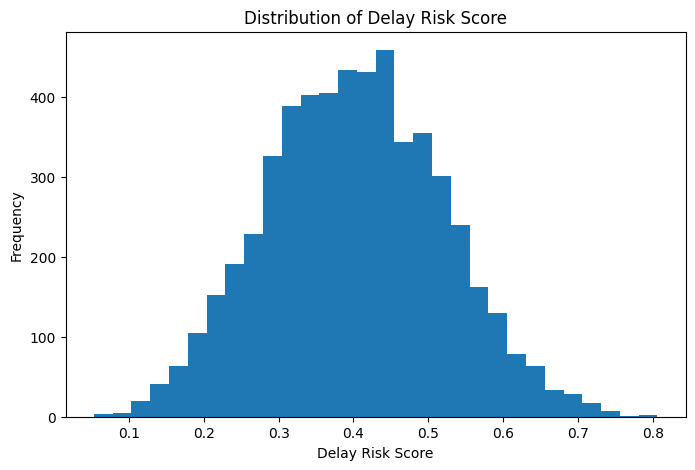

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    data_clean["delay_risk_score"],
    bins=30
)

plt.xlabel("Delay Risk Score")
plt.ylabel("Frequency")
plt.title("Distribution of Delay Risk Score")

plt.show()

In [36]:
threshold = (
    data_clean["delay_risk_score"].median()
)

print("Risk threshold:", threshold)

Risk threshold: 0.40137485612055085


In [37]:
data_clean["Delay"] = (
    data_clean["delay_risk_score"] >= threshold
).astype(int)

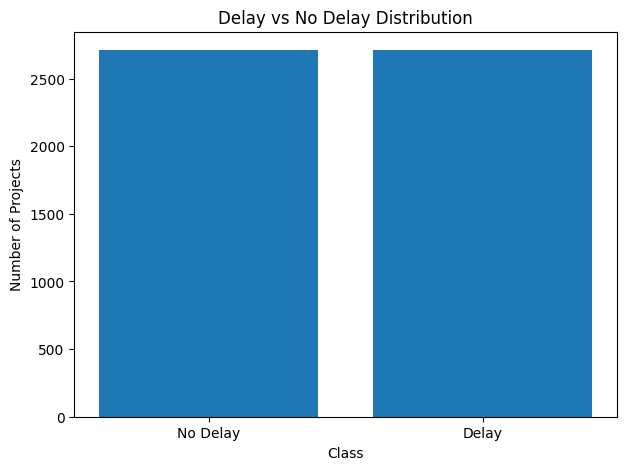

In [38]:
target_counts = (
    data_clean["Delay"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Delay", "Delay"],
    target_counts.values
)

plt.xlabel("Class")
plt.ylabel("Number of Projects")
plt.title("Delay vs No Delay Distribution")

plt.show()

In [39]:
target_percentage = (
    data_clean["Delay"]
    .value_counts(normalize=True)
    * 100
)

print(target_percentage)

Delay
1    50.009223
0    49.990777
Name: proportion, dtype: float64


In [40]:
comparison = data_clean.groupby(
    "Delay"
)[
    [
        "risk_score",
        "cost_deviation",
        "vibration_level",
        "safety_incidents",
        "equipment_utilization_rate",
        "material_shortage_alert"
    ]
].mean()

display(comparison)

,risk_score,cost_deviation,vibration_level,safety_incidents,equipment_utilization_rate,material_shortage_alert
Delay,,,,,,
0,36.968681,-1109.791818,20.791323,0.069373,79.078493,0.079336
1,65.039107,1165.786753,29.119591,0.136850,71.099476,0.297676


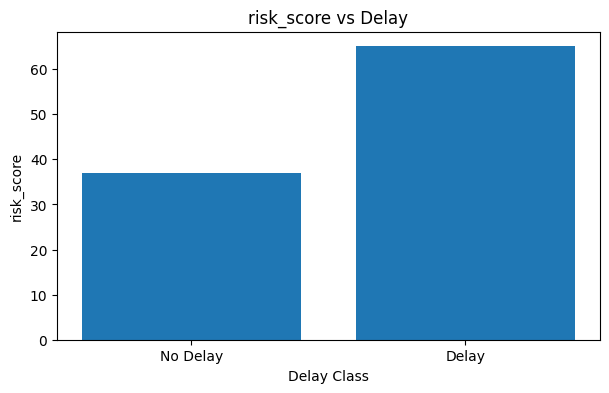

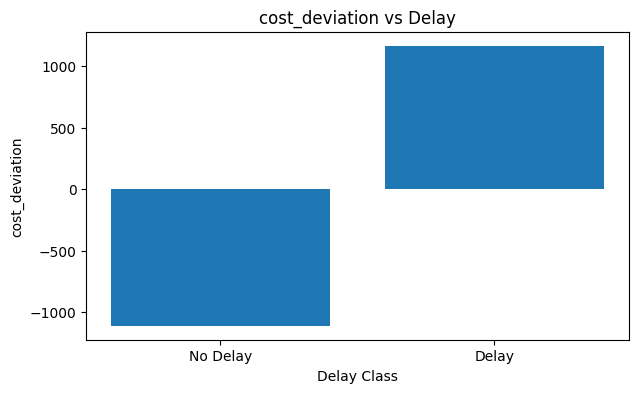

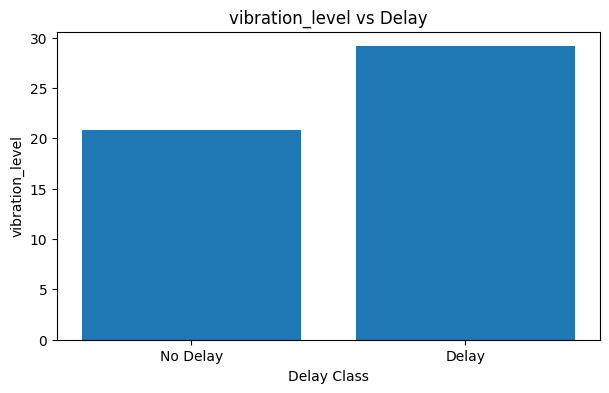

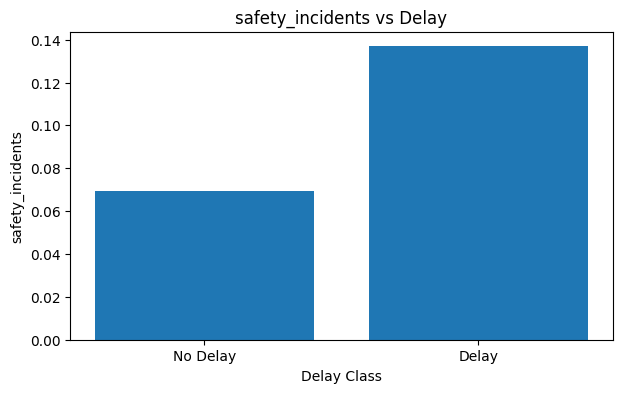

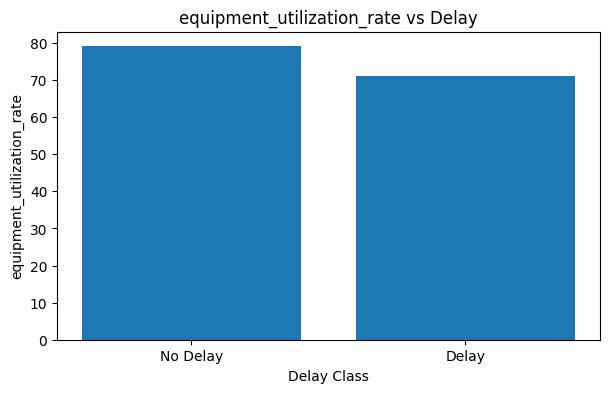

In [41]:
features_to_compare = [
    "risk_score",
    "cost_deviation",
    "vibration_level",
    "safety_incidents",
    "equipment_utilization_rate"
]

for feature in features_to_compare:

    grouped = data_clean.groupby(
        "Delay"
    )[feature].mean()

    plt.figure(figsize=(7, 4))

    plt.bar(
        ["No Delay", "Delay"],
        grouped.values
    )

    plt.xlabel("Delay Class")
    plt.ylabel(feature)
    plt.title(
        f"{feature} vs Delay"
    )

    plt.show()

In [42]:
drop_columns = [
    "Delay",
    "delay_risk_score",
    "time_deviation",
    "performance_score",
    "optimization_suggestion",
    "timestamp"
]

In [43]:
X = data_clean.drop(
    columns=drop_columns,
    errors="ignore"
)

y = data_clean["Delay"]

In [44]:
print("X shape:", X.shape)

print("\nFeatures:")
for feature in X.columns:
    print("→", feature)

X shape: (5421, 24)

Features:
→ temperature
→ humidity
→ vibration_level
→ material_usage
→ machinery_status
→ worker_count
→ energy_consumption
→ task_progress
→ cost_deviation
→ safety_incidents
→ equipment_utilization_rate
→ material_shortage_alert
→ risk_score
→ simulation_deviation
→ update_frequency
→ hour
→ day
→ dayofweek
→ month
→ worker_productivity
→ material_efficiency
→ equipment_efficiency
→ environmental_stress
→ safety_risk


In [45]:
print(X.dtypes)

temperature                   float64
humidity                      float64
vibration_level               float64
material_usage                float64
machinery_status              float64
worker_count                  float64
energy_consumption            float64
task_progress                 float64
cost_deviation                float64
safety_incidents              float64
equipment_utilization_rate    float64
material_shortage_alert       float64
risk_score                    float64
simulation_deviation          float64
update_frequency              float64
hour                          float64
day                           float64
dayofweek                     float64
month                         float64
worker_productivity           float64
material_efficiency           float64
equipment_efficiency          float64
environmental_stress          float64
safety_risk                   float64
dtype: object


In [46]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [47]:
print(
    "Final X shape:",
    X.shape
)

Final X shape: (5421, 24)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (4336, 24)
Testing data : (1085, 24)


In [49]:
train_imputer = SimpleImputer(
    strategy="median"
)

X_train = pd.DataFrame(
    train_imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    train_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [50]:
print(
    "Missing values in X_train:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isnull().sum().sum()
)

Missing values in X_train: 0
Missing values in X_test: 0


In [51]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest training completed!"
)

Random Forest training completed!


In [52]:
rf_pred = rf_model.predict(
    X_test
)

rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

In [53]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("========== RANDOM FOREST ==========")

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

========== RANDOM FOREST ==========
Accuracy : 0.9354838709677419
Precision: 0.9245960502692998
Recall   : 0.9484346224677717
F1 Score : 0.9363636363636364
ROC-AUC  : 0.9890267272838474


In [54]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "No Delay",
            "Delay"
        ]
    )
)

              precision    recall  f1-score   support

    No Delay       0.95      0.92      0.93       542
       Delay       0.92      0.95      0.94       543

    accuracy                           0.94      1085
   macro avg       0.94      0.94      0.94      1085
weighted avg       0.94      0.94      0.94      1085



In [55]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

print(cm_rf)

[[500  42]
 [ 28 515]]


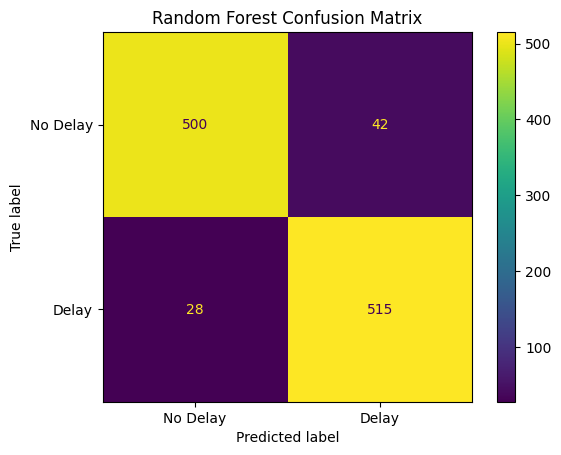

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=[
        "No Delay",
        "Delay"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [57]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    gamma=0,
    reg_alpha=0.05,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost training completed!"
)

XGBoost training completed!


In [58]:
xgb_pred = xgb_model.predict(
    X_test
)

xgb_probability = (
    xgb_model.predict_proba(
        X_test
    )[:, 1]
)

In [59]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probability
)

print("============= XGBOOST =============")

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

============= XGBOOST =============
Accuracy : 0.96036866359447
Precision: 0.9595588235294118
Recall   : 0.9613259668508287
F1 Score : 0.9604415823367065
ROC-AUC  : 0.9956236026448663


In [60]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "No Delay",
            "Delay"
        ]
    )
)

              precision    recall  f1-score   support

    No Delay       0.96      0.96      0.96       542
       Delay       0.96      0.96      0.96       543

    accuracy                           0.96      1085
   macro avg       0.96      0.96      0.96      1085
weighted avg       0.96      0.96      0.96      1085



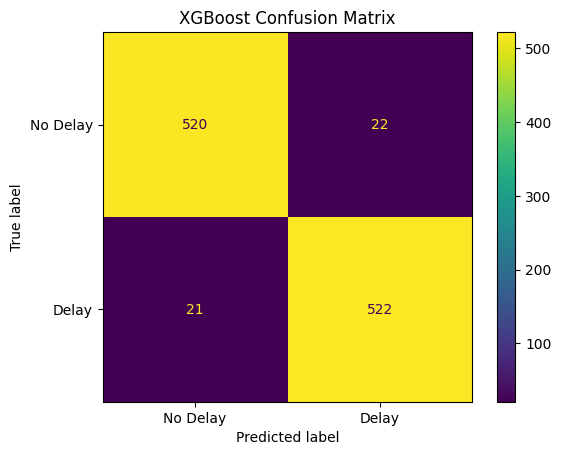

In [61]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=[
        "No Delay",
        "Delay"
    ]
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

In [62]:
results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        rf_auc,
        xgb_auc
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.935484,0.924596,0.948435,0.936364,0.989027
1,XGBoost,0.960369,0.959559,0.961326,0.960442,0.995624


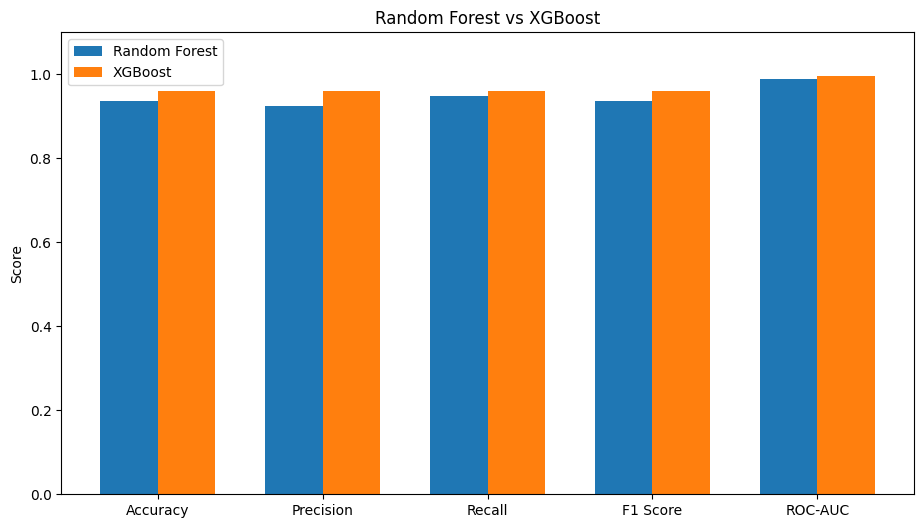

In [63]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    results.iloc[0][metrics],
    width,
    label="Random Forest"
)

plt.bar(
    x + width/2,
    results.iloc[1][metrics],
    width,
    label="XGBoost"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.title(
    "Random Forest vs XGBoost"
)

plt.legend()

plt.ylim(0, 1.1)

plt.show()

In [64]:
rf_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
        rf_model.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    rf_importance
)

,Feature,Importance
12,risk_score,0.255383
8,cost_deviation,0.173584
2,vibration_level,0.101815
10,equipment_utilization_rate,0.097810
11,material_shortage_alert,0.059043
13,simulation_deviation,0.024355
1,humidity,0.024347
3,material_usage,0.024235
6,energy_consumption,0.023846
0,temperature,0.023729


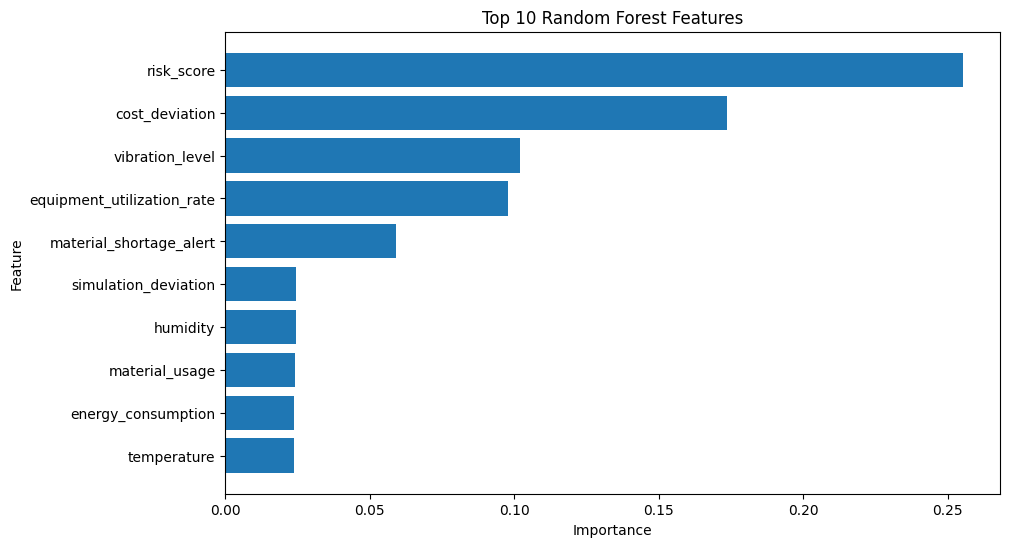

In [65]:
top_rf = rf_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 10 Random Forest Features"
)

plt.gca().invert_yaxis()

plt.show()

In [66]:
xgb_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
        xgb_model.feature_importances_

})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    xgb_importance
)

,Feature,Importance
12,risk_score,0.168230
8,cost_deviation,0.135741
11,material_shortage_alert,0.133131
10,equipment_utilization_rate,0.096354
2,vibration_level,0.086661
23,safety_risk,0.067595
9,safety_incidents,0.062962
4,machinery_status,0.017972
18,month,0.017148
3,material_usage,0.016521


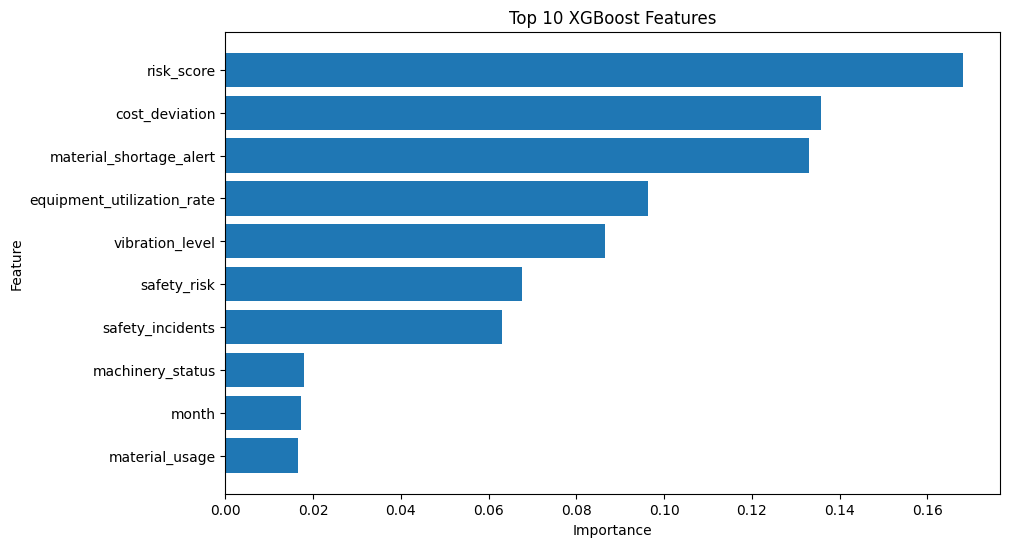

In [67]:
top_xgb = xgb_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb["Feature"],
    top_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 10 XGBoost Features"
)

plt.gca().invert_yaxis()

plt.show()

In [68]:
import sys
print(sys.executable)

import numpy as np
print(np.__version__)

import shap
print(shap.__version__)

C:\Users\KARTHIK\OneDrive\Desktop\karthik sem\construction_env\Scripts\python.exe
2.2.6
0.49.1


In [69]:
import shap

In [70]:
if xgb_f1 >= rf_f1:

    best_model = xgb_model
    best_model_name = "XGBoost"

else:

    best_model = rf_model
    best_model_name = "Random Forest" 

print(
    "Best model:",
    best_model_name
)

Best model: XGBoost


In [71]:
import joblib

joblib.dump(
    best_model,
    "construction_delay_model.pkl"
)

print(
    "Best model saved successfully!"
)

Best model saved successfully!


In [72]:
joblib.dump(
    train_imputer,
    "construction_delay_imputer.pkl"
)

print(
    "Imputer saved successfully!"
)

Imputer saved successfully!


In [73]:
joblib.dump(
    list(X_train.columns),
    "construction_delay_features.pkl"
)

print(
    "Feature names saved successfully!"
)

Feature names saved successfully!


In [74]:
new_project = pd.DataFrame({

    "temperature": [27],

    "humidity": [70],

    "vibration_level": [11],

    "material_usage": [500],

    "machinery_status": [3],

    "worker_count": [30],

    "energy_consumption": [300],

    "task_progress": [80],

    "cost_deviation": [300],

    "safety_incidents": [3],

    "equipment_utilization_rate": [70],

    "material_shortage_alert": [1],

    "risk_score": [80],

    "simulation_deviation": [10],

    "update_frequency": [5],

    "hour": [14],

    "day": [15],

    "dayofweek": [2],

    "month": [9]
})

In [75]:
new_project["worker_productivity"] = (
    new_project["task_progress"] /
    (new_project["worker_count"] + 1)
)

new_project["material_efficiency"] = (
    new_project["task_progress"] /
    (new_project["material_usage"] + 1)
)

new_project["equipment_efficiency"] = (
    new_project["task_progress"] /
    (new_project["energy_consumption"] + 1)
)

new_project["environmental_stress"] = (
    new_project["temperature"] *
    new_project["humidity"] / 100
)

new_project["safety_risk"] = (
    new_project["safety_incidents"] *
    new_project["risk_score"]
)

In [76]:
new_project = new_project[
    X_train.columns
]

new_project = pd.DataFrame(
    train_imputer.transform(
        new_project
    ),
    columns=X_train.columns
)

In [77]:
prediction = best_model.predict(
    new_project
)[0]

probability = best_model.predict_proba(
    new_project
)[0][1]

if prediction == 1:
    result = "DELAY"
else:
    result = "NO DELAY"

print("Prediction:", result)

print(
    f"Delay probability: {probability:.2%}"
)

Prediction: DELAY
Delay probability: 99.98%
